# Notebook 3/3 — Evaluation & Attention Analysis

**Pipeline**: Heterogeneous RGAT for Source-Code Graph Link Prediction

This notebook covers three questions:

1. **Did the model learn?** — Per-relation AUC/AP table, ROC & PR curves, training history
2. **Are the embeddings useful?** — Logit score distributions (positive vs. negative edge separability)
3. **Is attention informative?** — Attention heatmap, top-attended edges by name, entropy diagnostic

**Prerequisites**: Run `01_preprocessing.ipynb` and `02_training.ipynb` first.


## 1. Imports & Setup

In [1]:
%pip install torch_geometric sentence-transformers igraph leidenalg --quiet

In [2]:
# ── Colab Setup ──────────────────────────────────────────────────────
import shutil, zipfile
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/MSAAI/capstone")
PROJECT_ROOT = Path("/content/rgat_project")
PROJECT_ROOT.mkdir(exist_ok=True)

# Always re-extract source code to pick up any changes
zip_src = DRIVE_DIR / "rgat_source.zip"
for pkg in ["rgat", "graph_builder"]:
    old = PROJECT_ROOT / pkg
    if old.exists():
        shutil.rmtree(old)
with zipfile.ZipFile(zip_src, "r") as zf:
    zf.extractall(PROJECT_ROOT)
print("✓ Source code extracted (fresh)")

for d in ["artifacts", "cache", "checkpoints"]:
    (PROJECT_ROOT / d).mkdir(exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Source code extracted (fresh)
PROJECT_ROOT = /content/rgat_project


In [3]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# PROJECT_ROOT set in Colab setup cell
sys.path.insert(0, str(PROJECT_ROOT))

# Force-reload source modules in case the kernel cached an older version
for mod_name in list(sys.modules):
    if mod_name.startswith("rgat"):
        del sys.modules[mod_name]

from rgat.config import RGATConfig
from rgat.model import HeteroRGATEncoder, LinkPredictor
from rgat.training import evaluate_link_prediction
from rgat.attention import get_attention_weights, attention_to_dataframe

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
print(f"PyTorch {torch.__version__}")

PyTorch 2.10.0+cu128


## 2. Load Model & Data

Reconstruct the encoder from the saved config, load the best checkpoint, and load the validation data.

In [4]:
# Load config
config_dict = torch.load(ARTIFACTS_DIR / "config.pt", weights_only=False)
config = RGATConfig(**config_dict)

# Override with improved hyperparameters (must match training)
config.num_heads = 8
config.num_layers = 3
config.diversity_loss_weight = 1.0

config.resolve_device()
device = torch.device(config.device)

# Load val data
val_data = torch.load(ARTIFACTS_DIR / "val_data.pt", weights_only=False)

# Load model metadata
model_meta = torch.load(ARTIFACTS_DIR / "model_metadata.pt", weights_only=False)
all_node_types = model_meta["all_node_types"]
all_edge_types = model_meta["all_edge_types"]

# Load node index
with open(ARTIFACTS_DIR / "node_index.json") as f:
    node_index = json.load(f)

# Reconstruct model
encoder = HeteroRGATEncoder(
    node_types=all_node_types,
    edge_types=all_edge_types,
    scalar_dims=config.scalar_dims,
    sentence_dim=config.sentence_dim,
    leiden_embed_dim=config.leiden_embed_dim,
    num_leiden_ids=config.num_leiden_ids,
    hidden_dim=config.hidden_dim,
    num_heads=config.num_heads,
    num_layers=config.num_layers,
    dropout=config.dropout,
)
predictor = LinkPredictor()

# Load best checkpoint
ckpt_path = PROJECT_ROOT / "checkpoints" / "best_model.pt"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
encoder.load_state_dict(ckpt["encoder_state_dict"])
predictor.load_state_dict(ckpt["predictor_state_dict"])

encoder = encoder.to(device)
predictor = predictor.to(device)
val_data = val_data.to(device)

print(f"✓ Model loaded from {ckpt_path}")
print(f"  Device: {device}")
print(f"  num_heads={config.num_heads}, num_layers={config.num_layers}, diversity_loss_weight={config.diversity_loss_weight}")
print(f"  Encoder params: {sum(p.numel() for p in encoder.parameters()):,}")

✓ Model loaded from /content/rgat_project/checkpoints/best_model.pt
  Device: cuda
  num_heads=8, num_layers=3, diversity_loss_weight=1.0
  Encoder params: 4,037,808


## 3. Final Evaluation — Per-Relation Metrics

Evaluate on the validation set and display per-relation loss, accuracy, ROC-AUC, and average precision.

In [5]:
# Identify supervised triplets
supervised_triplets = [
    t for t in val_data.edge_types
    if t[1] in config.supervised_relations
    and hasattr(val_data[t], "edge_label_index")
]

criterion = nn.BCEWithLogitsLoss()
per_rel, total_loss = evaluate_link_prediction(
    encoder, predictor, val_data, supervised_triplets, criterion,
)

# Display as a nice table
rows = []
for triplet, m in per_rel.items():
    rows.append({
        "Relation": f"({triplet[0]}, {triplet[1]}, {triplet[2]})",
        "Loss": f"{m.loss:.4f}",
        "Accuracy": f"{m.accuracy:.4f}",
        "ROC-AUC": f"{m.roc_auc:.4f}",
        "Avg Precision": f"{m.avg_precision:.4f}",
        "# Edges": f"{m.n_edges:,}",
    })
metrics_df = pd.DataFrame(rows)
display(metrics_df)

print(f"\nTotal validation loss: {total_loss:.4f}")

,Relation,Loss,Accuracy,ROC-AUC,Avg Precision,# Edges
0,"(class, INHERITS, class)",0.5928,0.6947,0.8254,0.8381,"2,430"
1,"(module, IMPORTS_MODULE, module)",0.7224,0.5047,0.7150,0.6830,"11,630"
2,"(function, CALLS, function)",0.6279,0.6386,0.7505,0.7738,"17,556"
3,"(function, CALLS, class)",0.6242,0.6375,0.7402,0.8053,"2,960"



Total validation loss: 2.5673


## 4. Per-Relation Metric Visualization

Bar chart comparison of ROC-AUC and Average Precision across supervised edge types.

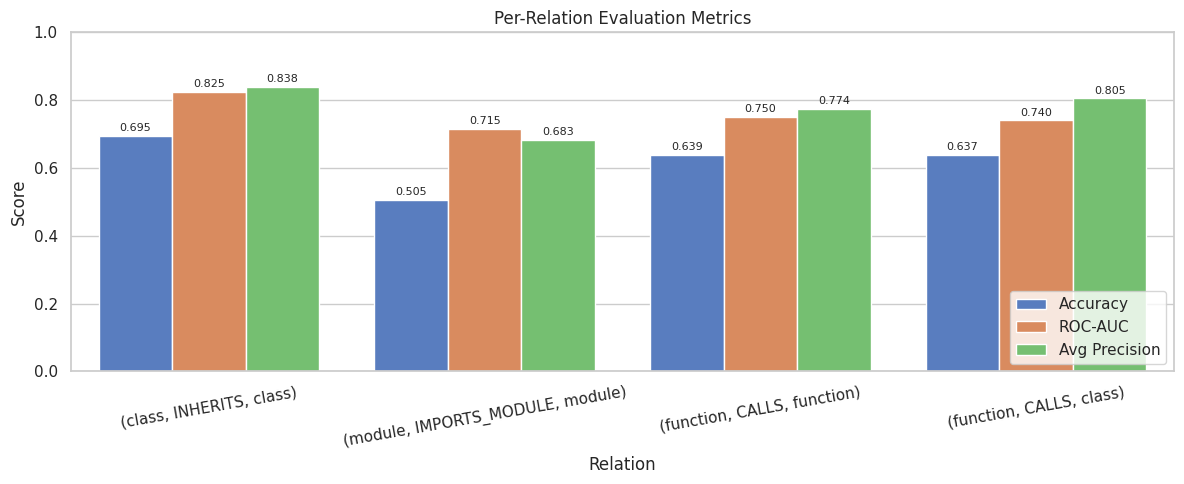

In [6]:
# ── Bar chart of metrics per relation ──
bar_rows = []
for triplet, m in per_rel.items():
    label = f"({triplet[0]}, {triplet[1]}, {triplet[2]})"
    bar_rows.append({"Relation": label, "Metric": "Accuracy",  "Value": m.accuracy})
    bar_rows.append({"Relation": label, "Metric": "ROC-AUC",   "Value": m.roc_auc})
    bar_rows.append({"Relation": label, "Metric": "Avg Precision", "Value": m.avg_precision})

bar_df = pd.DataFrame(bar_rows)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=bar_df, x="Relation", y="Value", hue="Metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Per-Relation Evaluation Metrics")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=10)
for container in ax.containers:
    ax.bar_label(container, fmt="{:.3f}", fontsize=8, padding=2)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. ROC and Precision-Recall Curves

Per-relation ROC and PR curves on the validation set.

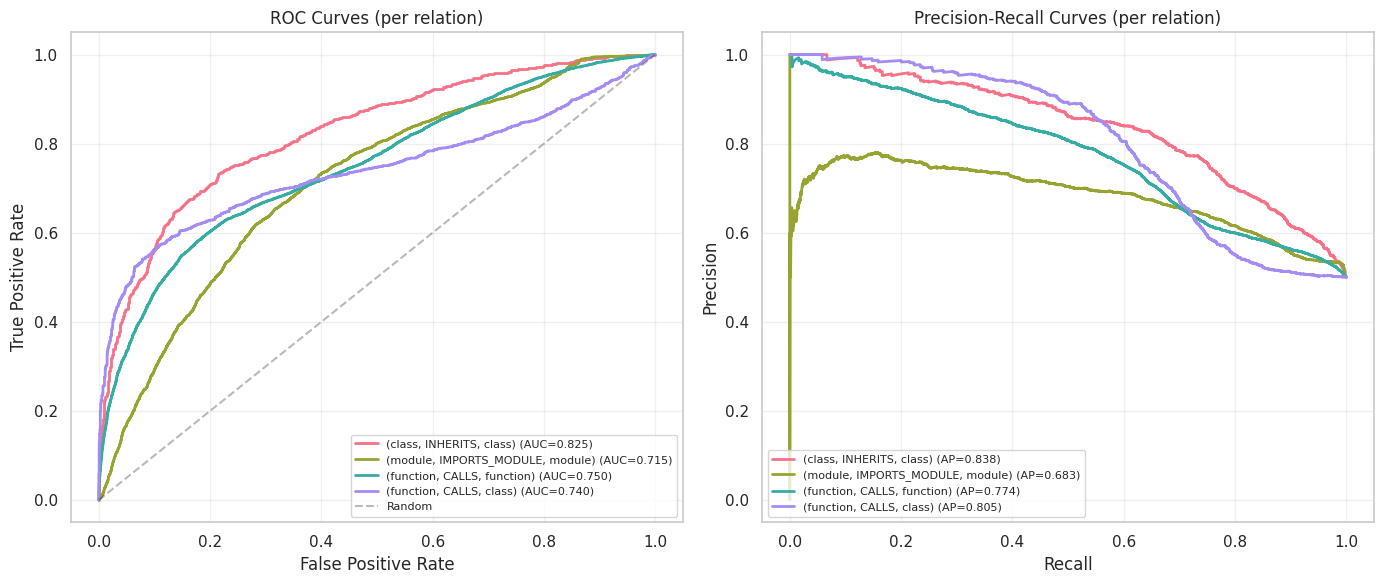

In [7]:
# Collect per-relation logits and labels for detailed curves
encoder.eval()
predictor.eval()

with torch.no_grad():
    z_dict = encoder(val_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = sns.color_palette("husl", len(supervised_triplets))

for idx, triplet in enumerate(supervised_triplets):
    src_type, rel, dst_type = triplet
    store = val_data[triplet]
    edge_label_index = store.edge_label_index
    edge_label = store.edge_label.float()

    z_src = z_dict[src_type][edge_label_index[0]]
    z_dst = z_dict[dst_type][edge_label_index[1]]
    logits = predictor(z_src, z_dst).cpu().numpy()
    labels = edge_label.cpu().numpy()

    label_str = f"({src_type}, {rel}, {dst_type})"
    color = colors[idx]

    # ROC curve
    fpr, tpr, _ = roc_curve(labels, logits)
    auc_val = roc_auc_score(labels, logits)
    axes[0].plot(fpr, tpr, label=f"{label_str} (AUC={auc_val:.3f})", color=color, linewidth=2)

    # PR curve
    precision, recall, _ = precision_recall_curve(labels, logits)
    ap_val = average_precision_score(labels, logits)
    axes[1].plot(recall, precision, label=f"{label_str} (AP={ap_val:.3f})", color=color, linewidth=2)

# ROC plot
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (per relation)")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR plot
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (per relation)")
axes[1].legend(fontsize=8, loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Score Distribution Analysis

Examine the distribution of predicted logits for positive vs. negative edges.

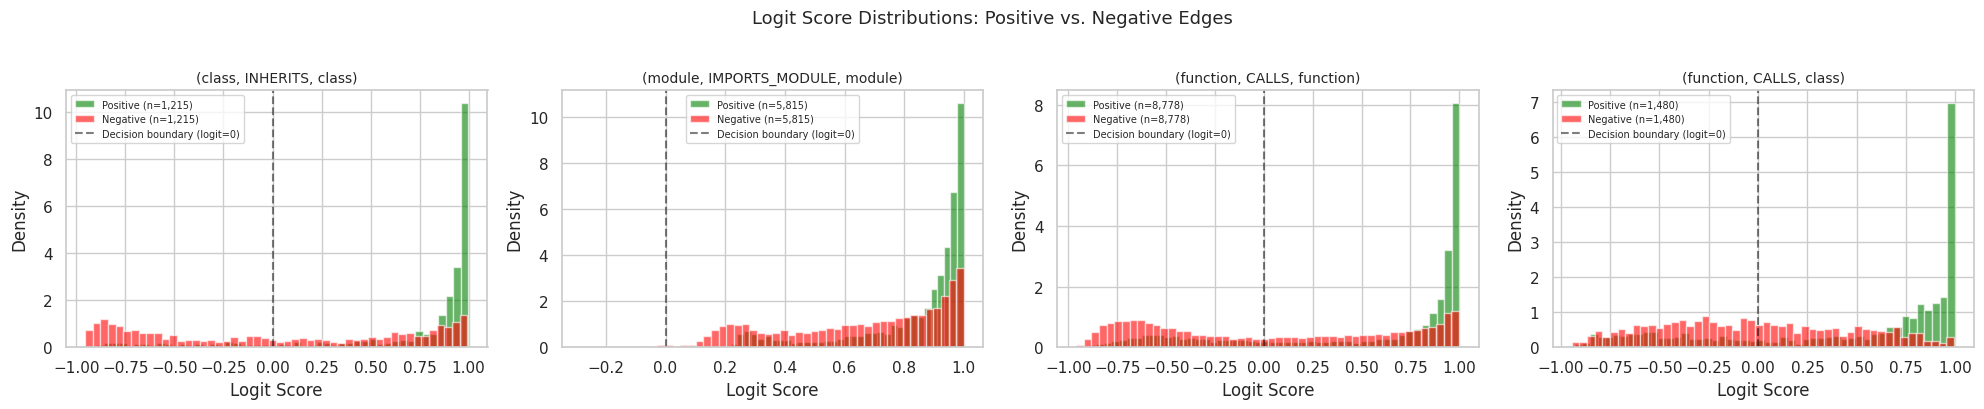

In [8]:
# Score distributions for positive vs negative edges
n_triplets = len(supervised_triplets)
fig, axes = plt.subplots(1, n_triplets, figsize=(5 * n_triplets, 4), squeeze=False)

with torch.no_grad():
    for idx, triplet in enumerate(supervised_triplets):
        src_type, rel, dst_type = triplet
        store = val_data[triplet]
        eli = store.edge_label_index
        labels = store.edge_label.cpu().numpy()

        z_src = z_dict[src_type][eli[0]]
        z_dst = z_dict[dst_type][eli[1]]
        logits = predictor(z_src, z_dst).cpu().numpy()

        ax = axes[0, idx]
        pos_scores = logits[labels == 1]
        neg_scores = logits[labels == 0]

        ax.hist(pos_scores, bins=50, alpha=0.6, label=f"Positive (n={len(pos_scores):,})",
                color="green", density=True)
        ax.hist(neg_scores, bins=50, alpha=0.6, label=f"Negative (n={len(neg_scores):,})",
                color="red", density=True)
        ax.axvline(0, color="black", linestyle="--", alpha=0.5, label="Decision boundary (logit=0)")
        ax.set_xlabel("Logit Score")
        ax.set_ylabel("Density")
        ax.set_title(f"({src_type}, {rel}, {dst_type})", fontsize=10)
        ax.legend(fontsize=7)

plt.suptitle("Logit Score Distributions: Positive vs. Negative Edges", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Training History Visualization

Load the saved training history and plot the learning dynamics.

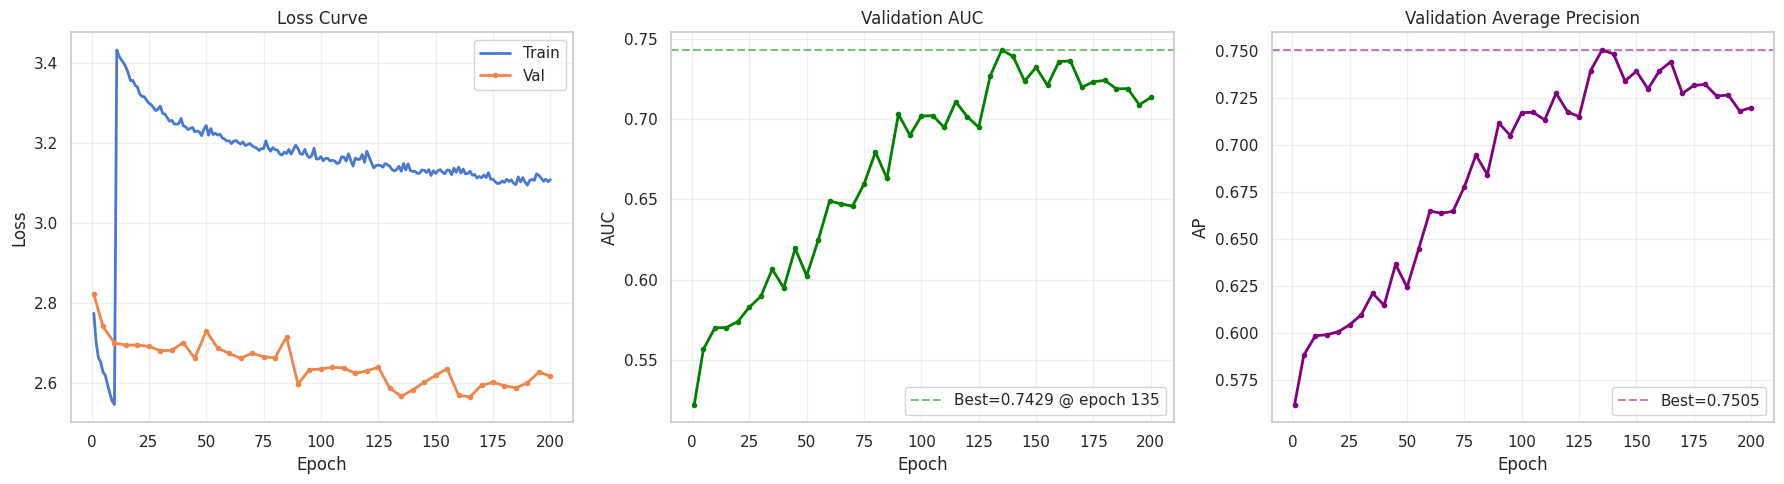

In [9]:
history = torch.load(ARTIFACTS_DIR / "training_history.pt", weights_only=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

val_every = config.val_every
val_epochs = [e for e in history["epoch"] if e == 1 or e % val_every == 0]

# Loss
ax = axes[0]
ax.plot(history["epoch"], history["train_loss"], label="Train", linewidth=2)
ax.plot(val_epochs[:len(history["val_loss"])], history["val_loss"],
        label="Val", linewidth=2, marker="o", markersize=3)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss Curve")
ax.legend(); ax.grid(True, alpha=0.3)

# AUC
ax = axes[1]
ax.plot(val_epochs[:len(history["val_auc"])], history["val_auc"],
        color="green", linewidth=2, marker="o", markersize=3)
best_auc = max(history["val_auc"])
best_ep = val_epochs[history["val_auc"].index(best_auc)]
ax.axhline(best_auc, color="green", linestyle="--", alpha=0.5,
           label=f"Best={best_auc:.4f} @ epoch {best_ep}")
ax.set_xlabel("Epoch"); ax.set_ylabel("AUC"); ax.set_title("Validation AUC")
ax.legend(); ax.grid(True, alpha=0.3)

# AP
ax = axes[2]
ax.plot(val_epochs[:len(history["val_ap"])], history["val_ap"],
        color="purple", linewidth=2, marker="o", markersize=3)
best_ap = max(history["val_ap"])
ax.axhline(best_ap, color="purple", linestyle="--", alpha=0.5,
           label=f"Best={best_ap:.4f}")
ax.set_xlabel("Epoch"); ax.set_ylabel("AP"); ax.set_title("Validation Average Precision")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Attention Weight Extraction

Extract per-layer, per-edge-type GATv2 attention weights by manually calling each sub-convolution with `return_attention_weights=True`. This reveals which edges (and relation types) the model attends to most strongly.

In [10]:
%%time

attn_maps = get_attention_weights(encoder, val_data)

# Summary — keys are now (src_type, rel, dst_type, scale)
total_entries = 0
attn_summary = []
for layer_idx, amap in enumerate(attn_maps):
    for (src_type, rel, dst_type, scale), (ei, alpha) in amap.items():
        n_edges = alpha.shape[0]
        n_heads = alpha.shape[1] if alpha.dim() == 2 else 1
        total_entries += n_edges
        attn_summary.append({
            "Layer": layer_idx,
            "Scale": scale,
            "Edge Type": f"({src_type}, {rel}, {dst_type})",
            "# Edges": n_edges,
            "# Heads": n_heads,
            "Mean α": float(alpha.mean()),
            "Std α": float(alpha.std()),
            "Max α": float(alpha.max()),
        })

attn_df = pd.DataFrame(attn_summary)
display(attn_df)
print(f"\nTotal attention entries: {total_entries:,}")


,Layer,Scale,Edge Type,# Edges,# Heads,Mean α,Std α,Max α
0,0,local,"(class, DEFINES_METHOD, function)",59592,4,1.000000,0.000000,1.0
1,0,local,"(class, INHERITS, class)",33366,4,0.793562,0.357087,1.0
2,0,local,"(class, DEFINES_CLASS, class)",30267,4,0.874814,0.247612,1.0
3,0,local,"(module, DEFINES_CLASS, class)",22689,4,1.000000,0.000000,1.0
4,0,local,"(module, DEFINES_FUNCTION, function)",21887,4,1.000000,0.000000,1.0
...,...,...,...,...,...,...,...,...
97,2,global,"(class, rev_DEFINES_CLASS, module)",22689,4,0.319097,0.374751,1.0
98,2,global,"(function, rev_DEFINES_FUNCTION, module)",21887,4,0.154932,0.232664,1.0
99,2,global,"(module, rev_IMPORTS_MODULE, module)",58999,4,0.205376,0.204125,1.0
100,2,global,"(function, rev_CALLS, function)",218208,4,0.373401,0.238884,1.0



Total attention entries: 5,321,901
CPU times: user 7.61 s, sys: 92.5 ms, total: 7.71 s
Wall time: 7.71 s


## 9. Attention Distribution Analysis

Visualize how attention is distributed across edge types and layers.

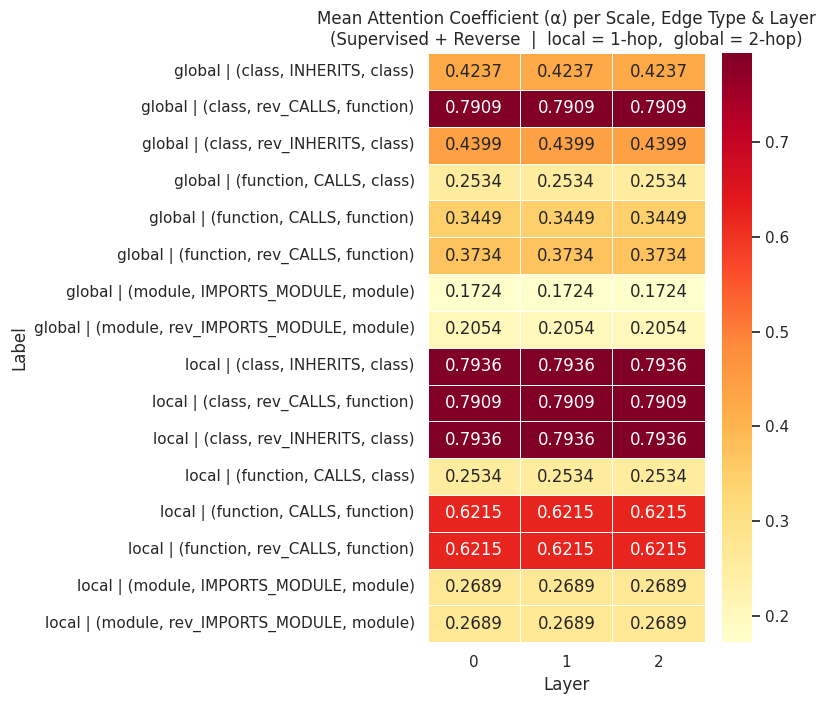

In [11]:
# ── 9a. Mean attention per scale, edge type, and layer (heatmap) ──
focus_rels = set()
for r in config.supervised_relations:
    focus_rels.add(r)
    focus_rels.add(f"rev_{r}")

focus_df = attn_df[attn_df["Edge Type"].apply(
    lambda x: any(r in x for r in focus_rels)
)].copy()

if len(focus_df) > 0:
    # Row label = "<scale> | <edge_type>" so local and global rows are distinct
    focus_df["Label"] = focus_df["Scale"] + " | " + focus_df["Edge Type"]
    pivot = focus_df.pivot_table(index="Label", columns="Layer", values="Mean α")
    fig, ax = plt.subplots(figsize=(8, max(4, len(pivot) * 0.45)))
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax, linewidths=0.5)
    ax.set_title(
        "Mean Attention Coefficient (α) per Scale, Edge Type & Layer\n"
        "(Supervised + Reverse  |  local = 1-hop,  global = 2-hop)"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No supervised edge types found in attention maps.")


## 10. Top-Attended Edges

Identify the edges with the highest mean attention across heads in the last layer, optionally mapping back to original node IDs.

In [12]:
# Build reverse node index: {node_type: {int_idx: node_id}}
node_index_reverse = {}
for ntype, id_map in node_index.items():
    node_index_reverse[ntype] = {int(idx): nid for nid, idx in id_map.items()}

# Get top-attended edges from last layer — show local and global scales
last_layer_attn = attn_maps[-1]

for triplet in supervised_triplets[:3]:   # top 3 relations
    src_type, rel, dst_type = triplet
    for scale in ("local", "global"):
        key = (src_type, rel, dst_type, scale)
        if key not in last_layer_attn:
            continue

        edge_index, alpha = last_layer_attn[key]
        mean_alpha = alpha.mean(dim=-1)   # [E]
        topk_vals, topk_idx = torch.topk(mean_alpha, min(10, len(mean_alpha)))

        print(f"\n{'─'*70}")
        print(f"  Top-attended [{scale}] edges: ({src_type}, {rel}, {dst_type})")
        print(f"{'─'*70}")

        for rank, (val, eidx) in enumerate(zip(topk_vals, topk_idx)):
            src_int = int(edge_index[0, eidx])
            dst_int = int(edge_index[1, eidx])
            src_id = node_index_reverse.get(src_type, {}).get(src_int, f"idx:{src_int}")
            dst_id = node_index_reverse.get(dst_type, {}).get(dst_int, f"idx:{dst_int}")
            src_short = src_id.split("::")[-1] if "::" in src_id else src_id
            dst_short = dst_id.split("::")[-1] if "::" in dst_id else dst_id
            print(f"  #{rank+1:2d}  α={val:.4f}  {src_short} → {dst_short}")



──────────────────────────────────────────────────────────────────────
  Top-attended [local] edges: (class, INHERITS, class)
──────────────────────────────────────────────────────────────────────
  # 1  α=1.0000  EmailAddressAdmin → EmailAddressAdmin
  # 2  α=1.0000  AppSettings → AppSettings
  # 3  α=1.0000  AuthenticationBackend → AuthenticationBackend
  # 4  α=1.0000  AppSettings.EmailVerificationMethod → AppSettings.EmailVerificationMethod
  # 5  α=1.0000  EmailConfirmationAdmin → EmailConfirmationAdmin
  # 6  α=1.0000  AppSettings.LoginMethod → AppSettings.LoginMethod
  # 7  α=1.0000  EmailField → EmailField
  # 8  α=1.0000  PhoneField → PhoneField
  # 9  α=1.0000  AccountConfig → AccountConfig
  #10  α=1.0000  AppSettings.AuthenticationMethod → AppSettings.AuthenticationMethod

──────────────────────────────────────────────────────────────────────
  Top-attended [global] edges: (class, INHERITS, class)
──────────────────────────────────────────────────────────────────────
  # 1

## 11. Attention Entropy — Is Attention Actually Informative?

The real question isn't whether *head 0 vs head 1* agree — it's whether **attention is discriminative at all**.

For each destination node `v`, the softmax over its in-neighbours produces a distribution.  
If that distribution is nearly **uniform** (every neighbour gets equal weight), attention is useless as an interpretability tool — the model might as well be doing mean-pooling.

**Normalised entropy** measures this:

$$\hat{H}_v = \frac{-\sum_u \alpha_{u \to v} \log \alpha_{u \to v}}{\log \, d^{in}(v)}$$

- $\hat{H} \approx 1$ → flat/uniform attention → **not informative**  
- $\hat{H} \approx 0$ → peaked attention → model has learned *which* neighbours matter

**Goal**: mean normalised entropy well below 1.0, ideally < 0.5 for supervised edge types.


ATTENTION ENTROPY SUMMARY (normalised, higher = more uniform)

Supervised edge types only:
 Scale                      Edge Type Head  Mean Norm. Entropy  Frac Peaked (H<0.5)
 local           (cla, INHERITS, cla)   H0            0.919315             0.022610
 local           (cla, INHERITS, cla)   H1            0.955499             0.003297
 local           (cla, INHERITS, cla)   H2            0.984616             0.002826
 local           (cla, INHERITS, cla)   H3            0.943497             0.008479
 local     (mod, IMPORTS_MODULE, mod)   H0            0.843110             0.100936
 local     (mod, IMPORTS_MODULE, mod)   H1            0.977019             0.008777
 local     (mod, IMPORTS_MODULE, mod)   H2            0.896093             0.045933
 local     (mod, IMPORTS_MODULE, mod)   H3            0.987019             0.007899
 local              (fun, CALLS, fun)   H0            0.976349             0.000903
 local              (fun, CALLS, fun)   H1            0.920042       

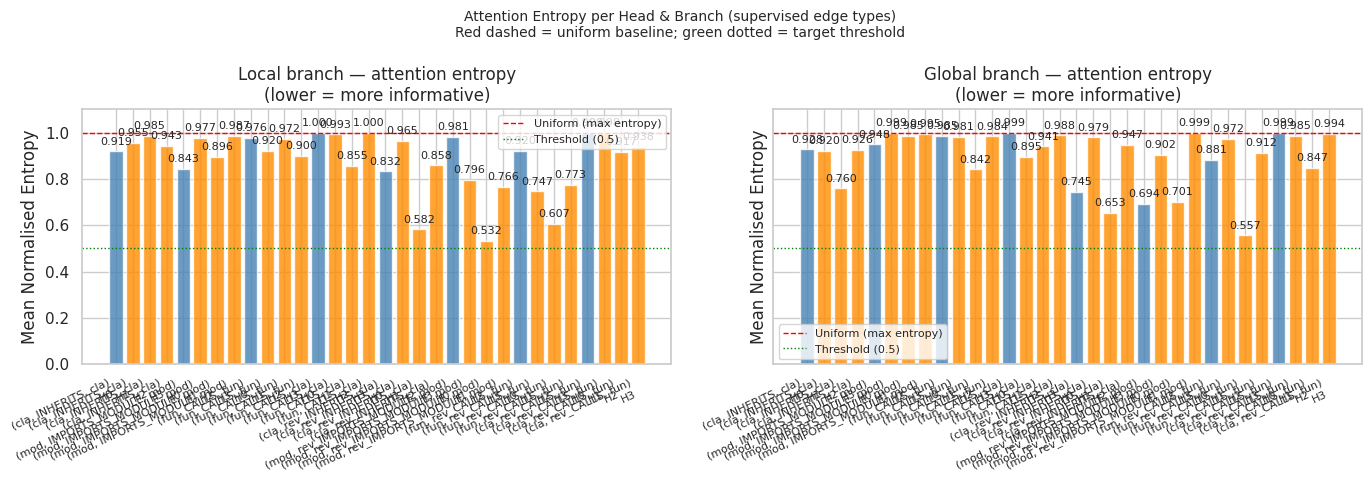

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

entropy_rows = []

for (src_type, rel, dst_type, scale), (ei, alpha) in last_layer_attn.items():
    if alpha.dim() != 2:
        continue
    ei_np = ei.cpu().numpy()          # [2, E]
    a_np  = alpha.detach().cpu().numpy()  # [E, H]
    dst_nodes = ei_np[1]              # destination node for each edge

    for h in range(a_np.shape[1]):
        head_ent = []
        for dst in np.unique(dst_nodes):
            mask = (dst_nodes == dst)
            w = a_np[mask, h]                  # attention weights for this node's in-neighbours
            w = np.clip(w, 1e-9, 1.0)          # numerical safety
            w = w / w.sum()                    # re-normalise (should already sum to ~1)
            deg = len(w)
            if deg < 2:
                continue                        # entropy undefined for degree-1 nodes
            H_raw = -np.sum(w * np.log(w))
            H_max = np.log(deg)               # uniform distribution entropy
            H_norm = H_raw / H_max            # 0 = peaked, 1 = uniform
            head_ent.append(H_norm)

        if head_ent:
            entropy_rows.append({
                "Scale": scale,
                "Edge Type": f"({src_type[:3]}, {rel}, {dst_type[:3]})",
                "Head": f"H{h}",
                "Mean Norm. Entropy": np.mean(head_ent),
                "Median Norm. Entropy": np.median(head_ent),
                "Frac Peaked (H<0.5)": np.mean(np.array(head_ent) < 0.5),
                "n_nodes": len(head_ent),
            })

ent_df = pd.DataFrame(entropy_rows)

print("=" * 65)
print("ATTENTION ENTROPY SUMMARY (normalised, higher = more uniform)")
print("=" * 65)
supervised_rels = set(config.supervised_relations)
sup_mask = ent_df["Edge Type"].apply(lambda x: any(r in x for r in supervised_rels))
print("\nSupervised edge types only:")
print(ent_df[sup_mask][["Scale", "Edge Type", "Head",
                          "Mean Norm. Entropy", "Frac Peaked (H<0.5)"]].to_string(index=False))

overall_mean = ent_df["Mean Norm. Entropy"].mean()
print(f"\nOverall mean normalised entropy (all edges): {overall_mean:.4f}")
if overall_mean > 0.8:
    print("⚠  Attention is nearly UNIFORM — close to degree-normalised mean pooling.")
    print("   The model is not learning *which* neighbours matter.")
elif overall_mean > 0.5:
    print("⚠  Attention is moderately peaked but still has room to improve.")
else:
    print("✓  Attention is well-peaked — the model distinguishes important neighbours.")

# ── Visualisation ──────────────────────────────────────────────────────────
sup_ent = ent_df[sup_mask].copy()
if len(sup_ent) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, scale in zip(axes, ["local", "global"]):
        sdf = sup_ent[sup_ent["Scale"] == scale]
        if sdf.empty:
            ax.set_visible(False)
            continue
        bars = ax.bar(
            range(len(sdf)),
            sdf["Mean Norm. Entropy"],
            color=["steelblue" if h == "H0" else "darkorange" for h in sdf["Head"]],
            alpha=0.8,
        )
        ax.axhline(1.0, color="red", linestyle="--", lw=1, label="Uniform (max entropy)")
        ax.axhline(0.5, color="green", linestyle=":", lw=1, label="Threshold (0.5)")
        ax.set_xticks(range(len(sdf)))
        ax.set_xticklabels(
            [f"{r['Edge Type']}\n{r['Head']}" for _, r in sdf.iterrows()],
            rotation=25, ha="right", fontsize=8,
        )
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("Mean Normalised Entropy")
        ax.set_title(f"{scale.capitalize()} branch — attention entropy\n(lower = more informative)")
        ax.legend(fontsize=8)
        for bar, val in zip(bars, sdf["Mean Norm. Entropy"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.suptitle("Attention Entropy per Head & Branch (supervised edge types)\n"
                 "Red dashed = uniform baseline; green dotted = target threshold",
                 fontsize=10)
    plt.tight_layout()
    plt.show()


In [16]:
# Quick overall entropy summary
import numpy as np
col = "Mean Norm. Entropy"
all_ent = ent_df[col].values
print(f"Overall mean normalised entropy: {np.mean(all_ent):.4f}  (prev run: 0.9219)")
print(f"  Min: {np.min(all_ent):.4f}  Max: {np.max(all_ent):.4f}")
print(f"  Heads below 0.5: {(all_ent < 0.5).sum()} / {len(all_ent)}")
print(f"  Heads below 0.7: {(all_ent < 0.7).sum()} / {len(all_ent)}")
print(f"  Heads below 0.9: {(all_ent < 0.9).sum()} / {len(all_ent)}")
print(f"  Heads below 0.95: {(all_ent < 0.95).sum()} / {len(all_ent)}")

Overall mean normalised entropy: 0.9044  (prev run: 0.9219)
  Min: 0.5316  Max: 0.9998
  Heads below 0.5: 0 / 104
  Heads below 0.7: 8 / 104
  Heads below 0.9: 34 / 104
  Heads below 0.95: 53 / 104
